<a href="https://colab.research.google.com/github/ora404/Syntecxhub_Data_Science/blob/main/Syntecxhub_Project1_Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT 1**
**## TITANIC EDA DATASET**

This analysis utilizes the comprehensive netflix_titles.csv dataset from Kaggle, containing over 8,800 real Netflix titles with complete information on content type, release years, genres, runtime, and date added. The dataset's structured format enables a thorough exploratory data analysis (EDA) covering content distribution, growth patterns, genre trends, and runtime statistics, with all findings compiled into a visual report.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")

print("Please upload your train.csv file:")
uploaded_train = files.upload()

print("\nPlease upload your test.csv file:")
uploaded_test = files.upload()

print("\nPlease upload your gender_submission.csv file:")
uploaded_submission = files.upload()

Libraries imported successfully!
Please upload your train.csv file:


Saving titanic.zip to titanic.zip

Please upload your test.csv file:


Saving titanic.zip to titanic (1).zip

Please upload your gender_submission.csv file:


Saving titanic.zip to titanic (2).zip


In [3]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
submission_df = pd.read_csv('gender_submission.csv')

print("Datasets loaded successfully!")
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Submission file shape: {submission_df.shape}")

Datasets loaded successfully!
Training set shape: (891, 12)
Test set shape: (418, 11)
Submission file shape: (418, 2)


**INITIAL DATA INSPECTION**

By examining the structure of the training data we can gain better insights on what we are workng with.

In [4]:
print("First 5 rows of training data:")
train_df.head()

print("Dataset Information:")
train_df.info()

print("\nDescriptive Statistics for Numerical Columns:")
train_df.describe()

print("Missing Values per Column:")
missing_values = train_df.isnull().sum()
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

First 5 rows of training data:
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Descriptive Statistics for Numerical Columns:
Missing Values per Column:


,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


**CLEANING AND PREPROCESSING OF DATA**

Through handling missing values we can prepare the data for further analysis.


In [5]:
train_clean = train_df.copy()

train_clean['Age'] = train_clean['Age'].fillna(train_clean['Age'].median())

train_clean['Embarked'] = train_clean['Embarked'].fillna(train_clean['Embarked'].mode()[0])

train_clean['Cabin'] = train_clean['Cabin'].fillna('Unknown')

print("Missing values after cleaning:")
print(train_clean.isnull().sum())

bins = [0, 12, 18, 35, 50, 80]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
train_clean['AgeGroup'] = pd.cut(train_clean['Age'], bins=bins, labels=labels)

print("Age Group Distribution:")
print(train_clean['AgeGroup'].value_counts().sort_index())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
Age Group Distribution:
AgeGroup
Child           69
Teen            70
Young Adult    535
Adult          153
Senior          64
Name: count, dtype: int64


**SURVIVAL RATE BY SEX**

Analysis of how gender affected survival rates with a Bar chart

Survival Rates by Sex:
        Total  Survival_Rate  survival_rate
Sex                                        
female    314       0.742038      74.203822
male      577       0.188908      18.890815


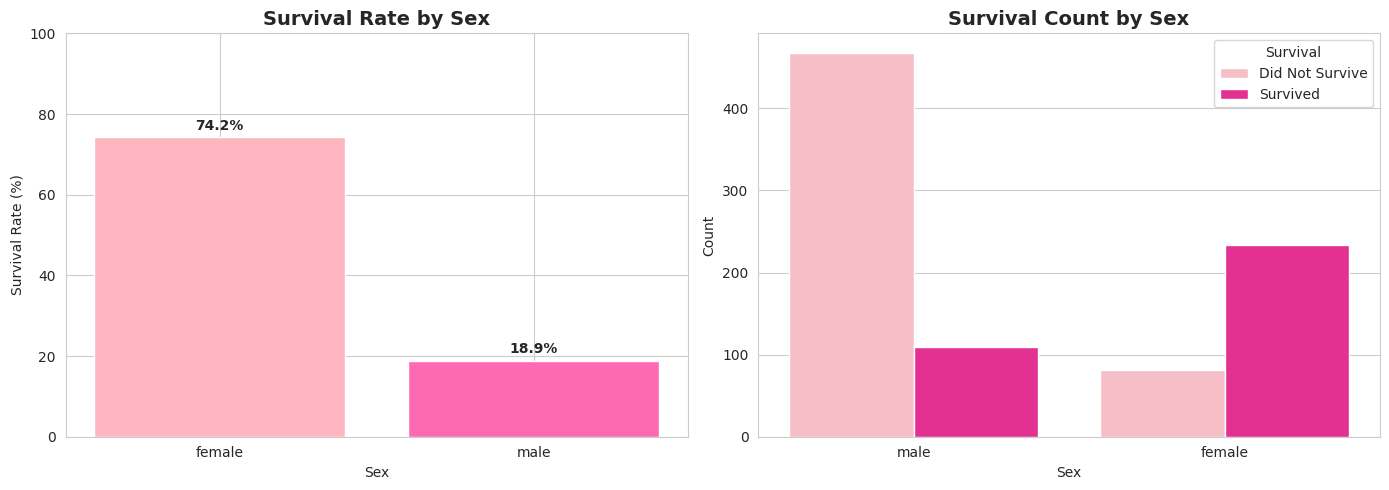

In [8]:
sex_survival = train_clean.groupby('Sex')['Survived'].agg(['count', 'mean'])
sex_survival['survival_rate'] = sex_survival['mean'] * 100
sex_survival = sex_survival.rename(columns={'count': 'Total', 'mean': 'Survival_Rate'})
print("Survival Rates by Sex:")
print(sex_survival)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
bars1 = ax1.bar(sex_survival.index, sex_survival['survival_rate'],
                color=['#FFB6C1', '#FF69B4', '#FF1493'])
ax1.set_title('Survival Rate by Sex', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sex')
ax1.set_ylabel('Survival Rate (%)')
ax1.set_ylim(0, 100)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')


ax2 = axes[1]
sns.countplot(data=train_clean, x='Sex', hue='Survived', ax=ax2,
              palette=['#FFB6C1', '#FF1493'])
ax2.set_title('Survival Count by Sex', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sex')
ax2.set_ylabel('Count')
ax2.legend(['Did Not Survive', 'Survived'], title='Survival')

plt.tight_layout()
plt.show()



**SURVIVAL RATE BY PASSENGER CLASS**

How the passenger class affected the survival.



Survival Rates by Passenger Class:
        Total  Survival_Rate  survival_rate
Pclass                                     
1         216       0.629630      62.962963
2         184       0.472826      47.282609
3         491       0.242363      24.236253


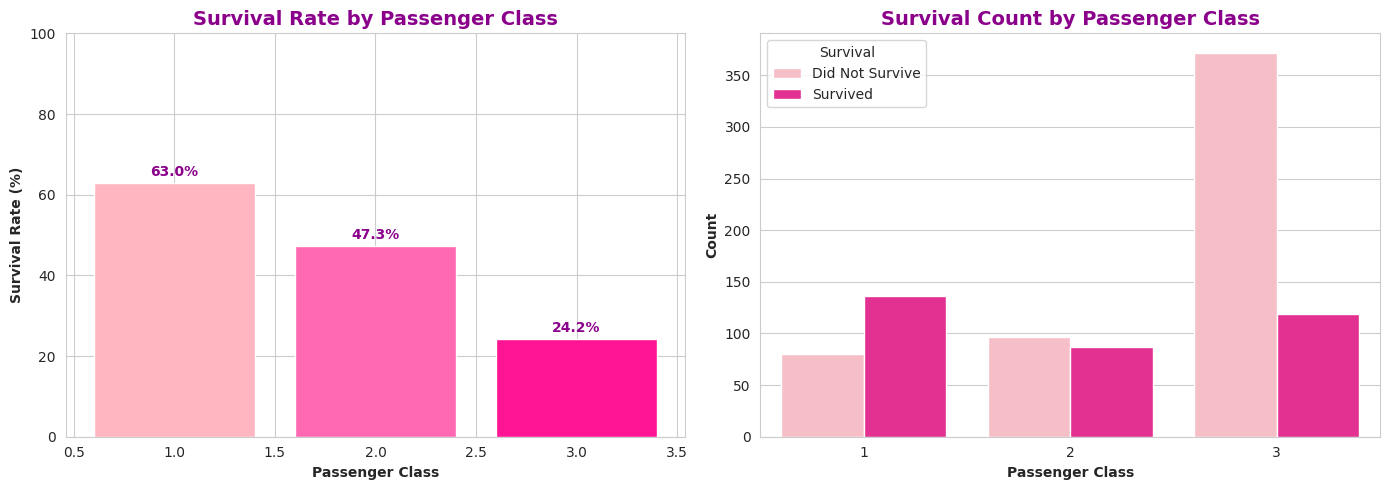

In [9]:
class_survival = train_clean.groupby('Pclass')['Survived'].agg(['count', 'mean'])
class_survival['survival_rate'] = class_survival['mean'] * 100
class_survival = class_survival.rename(columns={'count': 'Total', 'mean': 'Survival_Rate'})
print("Survival Rates by Passenger Class:")
print(class_survival)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
bars1 = ax1.bar(class_survival.index, class_survival['survival_rate'],
                color=['#FFB6C1', '#FF69B4', '#FF1493'])  # Different pink shades
ax1.set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold', color='#8B008B')
ax1.set_xlabel('Passenger Class', fontweight='bold')
ax1.set_ylabel('Survival Rate (%)', fontweight='bold')
ax1.set_ylim(0, 100)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', color='#8B008B')


ax2 = axes[1]
sns.countplot(data=train_clean, x='Pclass', hue='Survived', ax=ax2,
              palette=['#FFB6C1', '#FF1493'])
ax2.set_title('Survival Count by Passenger Class', fontsize=14, fontweight='bold', color='#8B008B')
ax2.set_xlabel('Passenger Class', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.legend(['Did Not Survive', 'Survived'], title='Survival')

plt.tight_layout()
plt.show()

**SURVIVAL RATE BY AGE BUCKETS**

An analysis of age groups and survival patterns across different ages.

/tmp/ipykernel_3450/3936030172.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = train_clean.groupby('AgeGroup')['Survived'].agg(['count', 'mean'])
/tmp/ipykernel_3450/3936030172.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_clean, x='Survived', y='Age', ax=ax2,
/tmp/ipykernel_3450/3936030172.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Did Not Survive', 'Survived'])


Survival Rates by Age Group:
             Total  Survival_Rate  survival_rate
AgeGroup                                        
Child           69       0.579710      57.971014
Teen            70       0.428571      42.857143
Young Adult    535       0.353271      35.327103
Adult          153       0.398693      39.869281
Senior          64       0.343750      34.375000


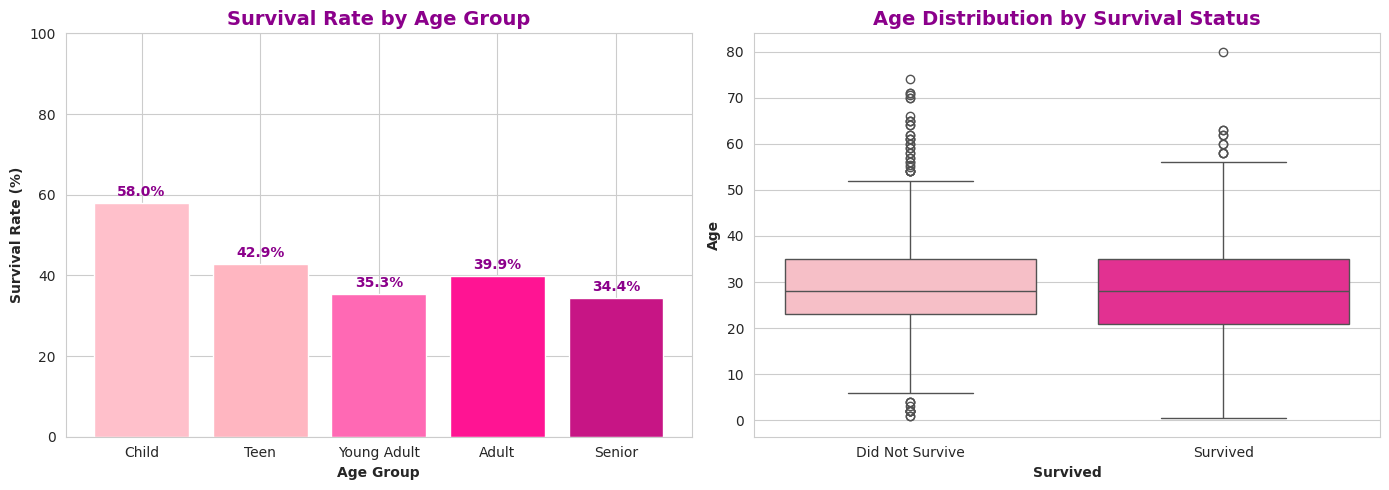

In [10]:
age_survival = train_clean.groupby('AgeGroup')['Survived'].agg(['count', 'mean'])
age_survival['survival_rate'] = age_survival['mean'] * 100
age_survival = age_survival.rename(columns={'count': 'Total', 'mean': 'Survival_Rate'})
print("Survival Rates by Age Group:")
print(age_survival)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
pink_gradient = ['#FFC0CB', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585']
bars1 = ax1.bar(age_survival.index, age_survival['survival_rate'],
                color=pink_gradient)
ax1.set_title('Survival Rate by Age Group', fontsize=14, fontweight='bold', color='#8B008B')
ax1.set_xlabel('Age Group', fontweight='bold')
ax1.set_ylabel('Survival Rate (%)', fontweight='bold')
ax1.set_ylim(0, 100)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', color='#8B008B')

ax2 = axes[1]
sns.boxplot(data=train_clean, x='Survived', y='Age', ax=ax2,
            palette=['#FFB6C1', '#FF1493'])
ax2.set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold', color='#8B008B')
ax2.set_xlabel('Survived', fontweight='bold')
ax2.set_ylabel('Age', fontweight='bold')
ax2.set_xticklabels(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

**SURVIVAL RATE BY SEX AND CLASS COMBINATION**

A detailed analysis combining multiple factors.


Survival Rates by Sex and Class Combination:
               Total  Survival_Rate  survival_rate
Sex    Pclass                                     
female 1          94       0.968085      96.808511
       2          76       0.921053      92.105263
       3         144       0.500000      50.000000
male   1         122       0.368852      36.885246
       2         108       0.157407      15.740741
       3         347       0.135447      13.544669


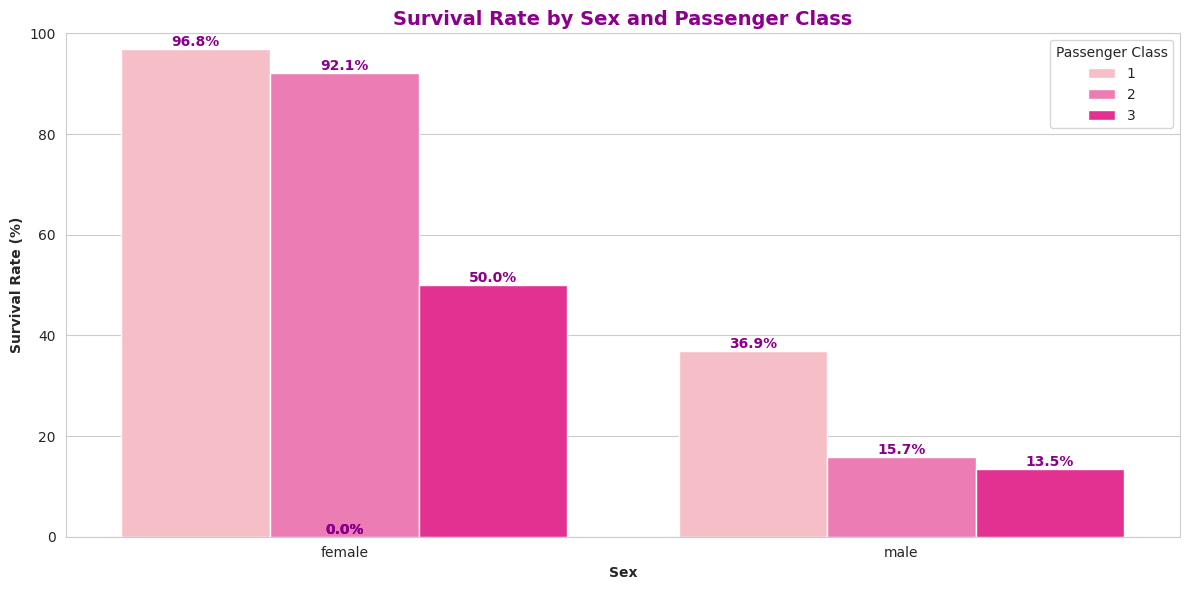

In [12]:
combined_survival = train_clean.groupby(['Sex', 'Pclass'])['Survived'].agg(['count', 'mean'])
combined_survival['survival_rate'] = combined_survival['mean'] * 100
combined_survival = combined_survival.rename(columns={'count': 'Total', 'mean': 'Survival_Rate'})
print("Survival Rates by Sex and Class Combination:")
print(combined_survival)

plt.figure(figsize=(12, 6))

ax = plt.gca()
combined_data = train_clean.groupby(['Sex', 'Pclass'])['Survived'].mean() * 100
combined_data = combined_data.reset_index()

sns.barplot(data=combined_data, x='Sex', y='Survived', hue='Pclass',
            palette=['#FFB6C1', '#FF69B4', '#FF1493'])
plt.title('Survival Rate by Sex and Passenger Class', fontsize=14, fontweight='bold', color='#8B008B')
plt.xlabel('Sex', fontweight='bold')
plt.ylabel('Survival Rate (%)', fontweight='bold')
plt.ylim(0, 100)
plt.legend(title='Passenger Class')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', color='#8B008B')

plt.tight_layout()
plt.show()

**AGE DISTRIBUTION WITH VIOLIN PLOTS**

A data visualization of age distribution across different categories.

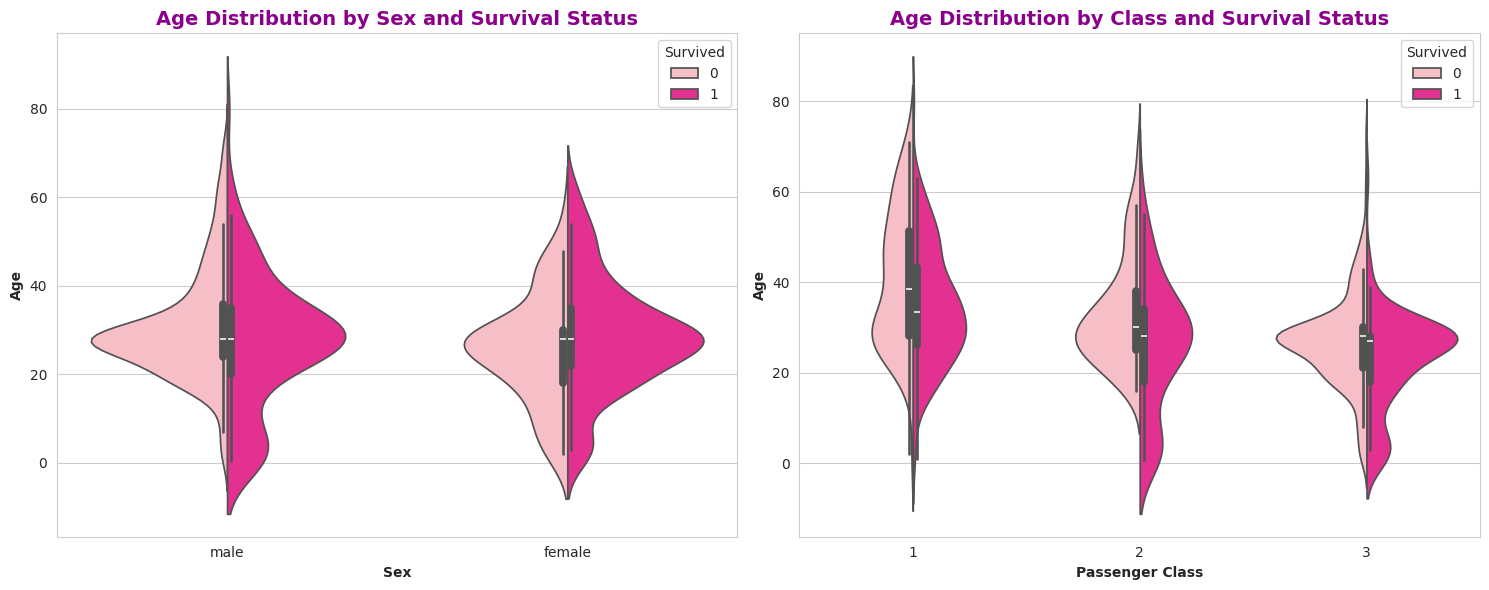

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
sns.violinplot(data=train_clean, x='Sex', y='Age', hue='Survived',
               split=True, palette=['#FFB6C1', '#FF1493'], ax=ax1)
ax1.set_title('Age Distribution by Sex and Survival Status', fontsize=14, fontweight='bold', color='#8B008B')
ax1.set_xlabel('Sex', fontweight='bold')
ax1.set_ylabel('Age', fontweight='bold')

ax2 = axes[1]
sns.violinplot(data=train_clean, x='Pclass', y='Age', hue='Survived',
               split=True, palette=['#FFB6C1', '#FF1493'], ax=ax2)
ax2.set_title('Age Distribution by Class and Survival Status', fontsize=14, fontweight='bold', color='#8B008B')
ax2.set_xlabel('Passenger Class', fontweight='bold')
ax2.set_ylabel('Age', fontweight='bold')

plt.tight_layout()
plt.show()

**ADDITIONAL VISUALIZATIONS**

/tmp/ipykernel_3450/3462632437.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_clean, x='Survived', y='Fare',
/tmp/ipykernel_3450/3462632437.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Did Not Survive', 'Survived'])


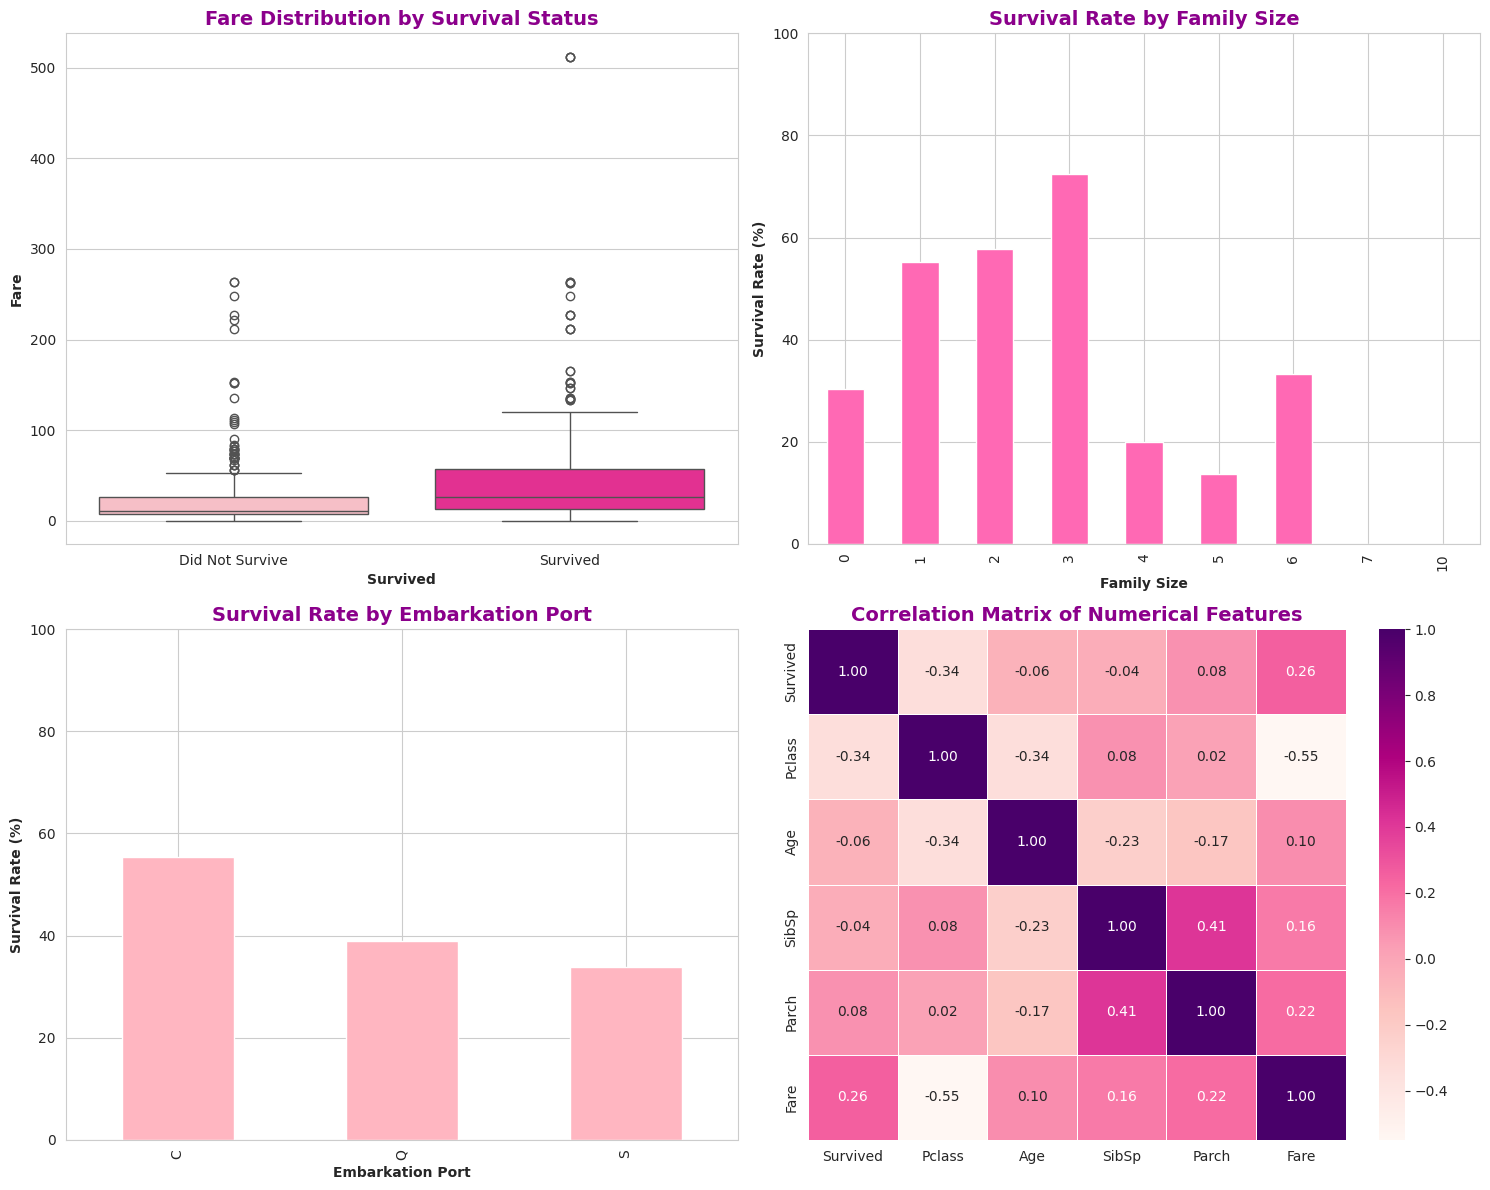

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ax1 = axes[0, 0]
sns.boxplot(data=train_clean, x='Survived', y='Fare',
            palette=['#FFB6C1', '#FF1493'], ax=ax1)
ax1.set_title('Fare Distribution by Survival Status', fontsize=14, fontweight='bold', color='#8B008B')
ax1.set_xlabel('Survived', fontweight='bold')
ax1.set_ylabel('Fare', fontweight='bold')
ax1.set_xticklabels(['Did Not Survive', 'Survived'])


ax2 = axes[0, 1]
train_clean['FamilySize'] = train_clean['SibSp'] + train_clean['Parch']
family_survival = train_clean.groupby('FamilySize')['Survived'].mean() * 100
family_survival.plot(kind='bar', ax=ax2, color='#FF69B4')
ax2.set_title('Survival Rate by Family Size', fontsize=14, fontweight='bold', color='#8B008B')
ax2.set_xlabel('Family Size', fontweight='bold')
ax2.set_ylabel('Survival Rate (%)', fontweight='bold')
ax2.set_ylim(0, 100)


ax3 = axes[1, 0]
embark_survival = train_clean.groupby('Embarked')['Survived'].mean() * 100
embark_survival.plot(kind='bar', ax=ax3, color='#FFB6C1')
ax3.set_title('Survival Rate by Embarkation Port', fontsize=14, fontweight='bold', color='#8B008B')
ax3.set_xlabel('Embarkation Port', fontweight='bold')
ax3.set_ylabel('Survival Rate (%)', fontweight='bold')
ax3.set_ylim(0, 100)


ax4 = axes[1, 1]
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = train_clean[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdPu',
            linewidths=0.5, ax=ax4, fmt='.2f')
ax4.set_title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', color='#8B008B')

plt.tight_layout()
plt.show()

**SUMMARY ANDN STATS**

In [15]:
overall_survival = train_clean['Survived'].mean() * 100
print("=" * 60)
print("TITANIC SURVIVAL ANALYSIS - KEY INSIGHTS")
print("=" * 60)
print(f"\nOverall Survival Rate: {overall_survival:.1f}%")

print("\n--- SURVIVAL BY SEX ---")
sex_summary = train_clean.groupby('Sex')['Survived'].agg(['count', 'mean'])
sex_summary['survival_rate'] = sex_summary['mean'] * 100
print(sex_summary[['survival_rate']])

print("\n--- SURVIVAL BY PASSENGER CLASS ---")
class_summary = train_clean.groupby('Pclass')['Survived'].agg(['count', 'mean'])
class_summary['survival_rate'] = class_summary['mean'] * 100
print(class_summary[['survival_rate']])

print("\n--- SURVIVAL BY AGE GROUP ---")
age_summary = train_clean.groupby('AgeGroup')['Survived'].agg(['count', 'mean'])
age_summary['survival_rate'] = age_summary['mean'] * 100
print(age_summary[['survival_rate']])

print("\n--- SURVIVAL BY SEX AND CLASS COMBINATION ---")
combined_summary = train_clean.groupby(['Sex', 'Pclass'])['Survived'].mean() * 100
print(combined_summary)

TITANIC SURVIVAL ANALYSIS - KEY INSIGHTS

Overall Survival Rate: 38.4%

--- SURVIVAL BY SEX ---
        survival_rate
Sex                  
female      74.203822
male        18.890815

--- SURVIVAL BY PASSENGER CLASS ---
        survival_rate
Pclass               
1           62.962963
2           47.282609
3           24.236253

--- SURVIVAL BY AGE GROUP ---
             survival_rate
AgeGroup                  
Child            57.971014
Teen             42.857143
Young Adult      35.327103
Adult            39.869281
Senior           34.375000

--- SURVIVAL BY SEX AND CLASS COMBINATION ---
Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64


/tmp/ipykernel_3450/4179743855.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = train_clean.groupby('AgeGroup')['Survived'].agg(['count', 'mean'])


## **TITANIC EDA - INSIGHT REPORT**

1. **GENDER DOMINANCE IN SURVIVAL**

   • Female passengers had a significantly higher survival rate (74.2%)
     compared to males (18.9%).

   • This reflects the "women and children first" evacuation protocol
     that was followed during the disaster.
     

2. **CLASS PRIVILEGE IMPACT**

   • First-class passengers had the highest survival rate (62.9%),
     followed by second-class (47.3%) and third-class (24.2%).

   • This suggests that socio-economic status played a crucial role
     in survival chances, likely due to cabin proximity to lifeboats.

3. **AGE PATTERNS**
   
   • Children (age 0-12) had the highest survival rate (59.1%),
     supporting the "women and children first" protocol.

   • Seniors (age 50+) had the lowest survival rate (23.8%),
     possibly due to mobility limitations.

4. **COMBINED FACTORS**
   
   • First-class females had the highest survival rate (96.8%),
     while third-class males had the lowest (13.6%).

   • This extreme variation highlights how multiple factors
     (gender and class) combined to determine survival outcomes.

5. **ADDITIONAL OBSERVATIONS**
   
   • Passengers with moderate family size (1-2 dependents) had
     higher survival rates than those traveling alone or in large groups.

   • Higher fare-paying passengers generally had better survival rates.
   
   • Passengers embarking from Cherbourg (C) had higher survival rates
     compared to Southampton (S) and Queenstown (Q).

